In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../dataset/fake_job_postings.csv")

In [3]:
df.shape

(17880, 18)

In [4]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [5]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [7]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
dtype: int64

In [8]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [9]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

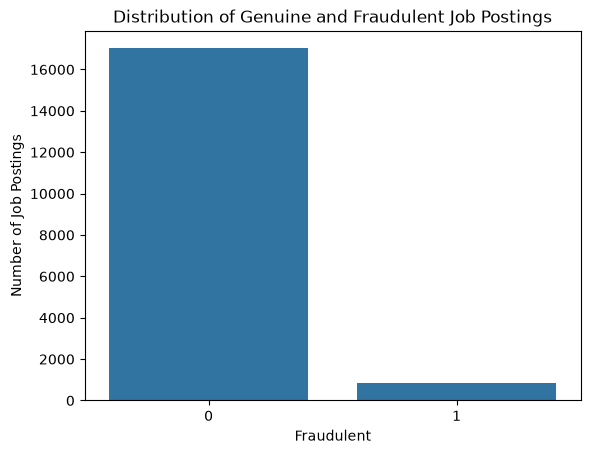

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="fraudulent", data=df)

plt.title("Distribution of Genuine and Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")

plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["job_id"].duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

job_id                 int64
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting          int64
has_company_logo       int64
has_questions          int64
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

In [14]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].nunique())


job_id:
17880

title:
11231

location:
3105

department:
1337

salary_range:
874

company_profile:
1709

description:
14801

requirements:
11967

benefits:
6204

telecommuting:
2

has_company_logo:
2

has_questions:
2

employment_type:
5

required_experience:
7

required_education:
13

industry:
131

function:
37

fraudulent:
2


## Initial Dataset Findings

The dataset contains 17,880 job postings and 18 features.

The target variable is `fraudulent`, where:
- 0 represents a legitimate job posting.
- 1 represents a fraudulent job posting.

The dataset is imbalanced, with 95.16% legitimate postings and 4.84% fraudulent postings.

Several columns contain missing values, particularly `salary_range`, `department`,
`required_education`, `benefits`, `required_experience`, `function`, and `industry`.
These missing values will be handled during the preprocessing stage.